In [264]:
# Librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Constantes
from scipy.constants import mu_0, pi

# Estilo de las gráficas
sns.set_theme()


In [265]:
def calcular_regresion_lineal(x, y):
    
    # Ajuste lineal con covarianza
    coeficientes, M_cov = np.polyfit(x, y, 1, cov=True)
    m, b = coeficientes
    error_m, error_b = np.sqrt(np.diag(M_cov))
    
    # Valores ajustados
    y_fit = m * np.array(x) + b
    
    # Calculo de R^2
    y = np.array(y)
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    R2 = 1 - ss_res / ss_tot

    print(
        f'''Regresión lineal:
{'-'*40}
Pendiente (m): ({m : .4g} ± {error_m: .4g})
Intercepto (b): ({b : .4g} ± {error_b : .4g})
R^2: {R2:.4g}'''
    )

    return m, b, error_m, error_b, R2


In [266]:
ruta_archivo = r'datos_sensor_fabricante.txt'

datos_fabricante_df = pd.read_csv(
    ruta_archivo, sep=',',
    skiprows=3, 
    names=[
        'intensidad_mT',
        'voltaje_V'
    ], 
    dtype={
        'intensidad_mT': np.float64,
        'voltaje_V': np.float64
    }, 
    index_col=False,  
    engine='python'
)

datos_fabricante_df

,intensidad_mT,voltaje_V
0,-100.0,0.86
1,-80.0,1.20
2,-60.0,1.40
3,-40.0,1.70
4,-20.0,2.10
5,0.0,2.50
6,20.0,2.70
7,40.0,3.10
8,60.0,3.40
9,80.0,3.80


In [267]:
x = datos_fabricante_df.intensidad_mT 
y = datos_fabricante_df.voltaje_V

m, b, error_m, error_b, *_ = calcular_regresion_lineal(x,y)


Regresión lineal:
----------------------------------------
Pendiente (m): ( 0.01661 ±  0.0003318)
Intercepto (b): ( 2.452 ±  0.02098)
R^2: 0.9964


In [268]:
radio_m = 1/10
n_vueltas = 20
corriente_A = 2

corriente_0_A = 1
corriente_f_A = 4.0
delta_i_A = 0.2

radio_0_m = 0.05
radio_f_m = 0.5
delta_r_m = 0.05

corrientes_simuladas_A = np.arange(corriente_0_A, corriente_f_A + delta_i_A, delta_i_A)
radios_simulados_m = np.arange(radio_0_m, radio_f_m + delta_r_m, delta_r_m)

# Bobinas de Helmholtz: B con corriente variable
B_corriente_simulado_mT = (2 * mu_0 * n_vueltas * corrientes_simuladas_A) / (radio_m * np.sqrt(5)) *1e3

# Bobinas de Helmholtz: B con radio variable
B_radio_simulado_mT = (2 * mu_0 * n_vueltas * corriente_A) / (radios_simulados_m * np.sqrt(5)) *1e3

# Alambre "infinito"
# B_corriente_simulado_mT = (corrientes_simuladas_A * mu_0) / (2 * pi * radio_m) * 1e3 

B_corriente_simulado_mT

array([0.22479407, 0.26975289, 0.3147117 , 0.35967051, 0.40462933,
       0.44958814, 0.49454696, 0.53950577, 0.58446459, 0.6294234 ,
       0.67438221, 0.71934103, 0.76429984, 0.80925866, 0.85421747,
       0.89917629])

In [269]:
voltaje_B_corriente_simulado = m * B_corriente_simulado_mT + b

voltaje_B_corriente_simulado_arduino = voltaje_B_corriente_simulado.round(5)
voltaje_B_corriente_simulado_arduino

array([2.45555, 2.4563 , 2.45705, 2.45779, 2.45854, 2.45929, 2.46003,
       2.46078, 2.46153, 2.46228, 2.46302, 2.46377, 2.46452, 2.46526,
       2.46601, 2.46676])

In [270]:
voltaje_B_radio_simulado = m * B_radio_simulado_mT + b

voltaje_B_radio_simulado_arduino = voltaje_B_radio_simulado.round(5)
voltaje_B_radio_simulado_arduino

array([2.46676, 2.45929, 2.4568 , 2.45555, 2.45481, 2.45431, 2.45395,
       2.45369, 2.45348, 2.45331])

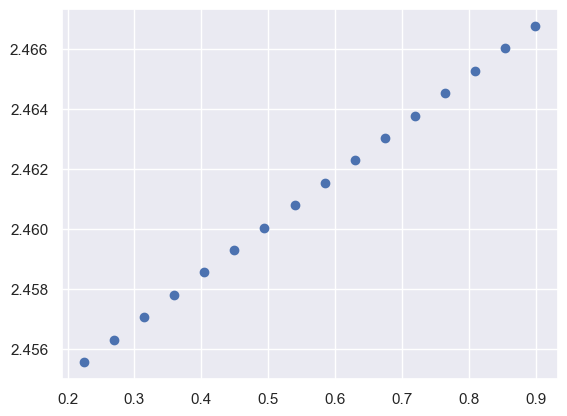

In [271]:
plt.scatter(B_corriente_simulado_mT, voltaje_B_corriente_simulado_arduino)

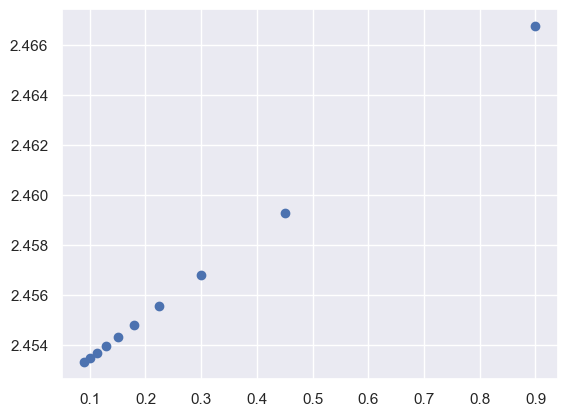

In [272]:
plt.scatter(B_radio_simulado_mT, voltaje_B_radio_simulado_arduino)

In [273]:
len(voltaje_B_corriente_simulado_arduino), len(voltaje_B_radio_simulado_arduino)

(16, 10)

In [274]:
x = np.array([-0.15, 0, 0.15])
y = np.array([0.86, 2.25, 4.21])

calcular_regresion_lineal(x,y)

Regresión lineal:
----------------------------------------
Pendiente (m): ( 11.17 ±  1.097)
Intercepto (b): ( 2.44 ±  0.1344)
R^2: 0.9904


(np.float64(11.166666666666666),
 np.float64(2.44),
 np.float64(1.0969655114602888),
 np.float64(0.13435028842544397),
 np.float64(0.9904419811487274))

In [275]:
datos_sensor_df = pd.read_excel(r'datos_final.xlsx')
datos_sensor_df.dropna(inplace=True)
datos_sensor_df

,corriente_A,campo_magnetico_uT,voltaje_sensor_V
0,0.01,12.3,2.484986
1,0.02,24.6,2.485533
2,0.03,36.9,2.482087
3,0.04,49.2,2.481007
4,0.05,61.5,2.480293
5,0.06,73.8,2.479022
6,0.07,86.1,2.478714
7,0.08,98.4,2.477766
8,0.09,110.7,2.477053
9,0.10,123.0,2.475767


In [276]:
datos_sensor_df['campo_magnetico_T'] = datos_sensor_df.campo_magnetico_uT * 1e-6
datos_sensor_df

,corriente_A,campo_magnetico_uT,voltaje_sensor_V,campo_magnetico_T
0,0.01,12.3,2.484986,0.000012
1,0.02,24.6,2.485533,0.000025
2,0.03,36.9,2.482087,0.000037
3,0.04,49.2,2.481007,0.000049
4,0.05,61.5,2.480293,0.000061
5,0.06,73.8,2.479022,0.000074
6,0.07,86.1,2.478714,0.000086
7,0.08,98.4,2.477766,0.000098
8,0.09,110.7,2.477053,0.000111
9,0.10,123.0,2.475767,0.000123


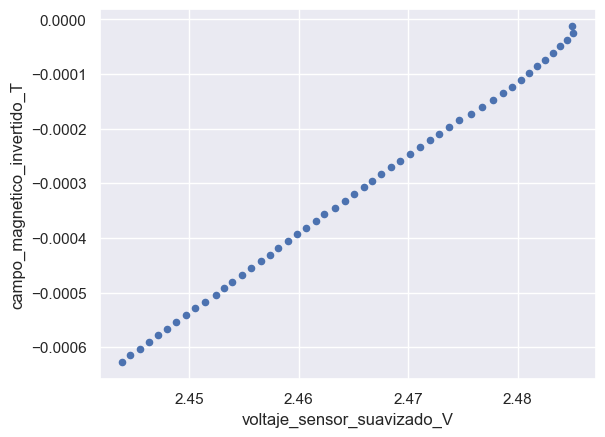

In [277]:
datos_sensor_df['voltaje_sensor_suavizado_V'] = datos_sensor_df.voltaje_sensor_V.ewm(span=10, adjust=False).mean()
datos_sensor_df['campo_magnetico_invertido_T'] = datos_sensor_df.campo_magnetico_T * -1

datos_sensor_df.plot(kind='scatter', x='voltaje_sensor_suavizado_V', y='campo_magnetico_invertido_T')
plt.show()

In [278]:
calcular_regresion_lineal(datos_sensor_df.voltaje_sensor_suavizado_V, datos_sensor_df.campo_magnetico_invertido_T)

Regresión lineal:
----------------------------------------
Pendiente (m): ( 0.01433 ±  5.411e-05)
Intercepto (b): (-0.03565 ±  0.0001334)
R^2: 0.9993


(np.float64(0.014333572940674385),
 np.float64(-0.03565403435143045),
 np.float64(5.4114468819666096e-05),
 np.float64(0.00013340137970145762),
 np.float64(0.9993020718009556))

In [279]:
calcular_regresion_lineal(datos_sensor_df.voltaje_sensor_V, datos_sensor_df.campo_magnetico_invertido_T)

Regresión lineal:
----------------------------------------
Pendiente (m): ( 0.01393 ±  0.0001013)
Intercepto (b): (-0.03462 ±  0.0002493)
R^2: 0.9974


(np.float64(0.01393365702714128),
 np.float64(-0.03461765632634166),
 np.float64(0.00010128709947487987),
 np.float64(0.00024932281991533073),
 np.float64(0.9974174361206719))

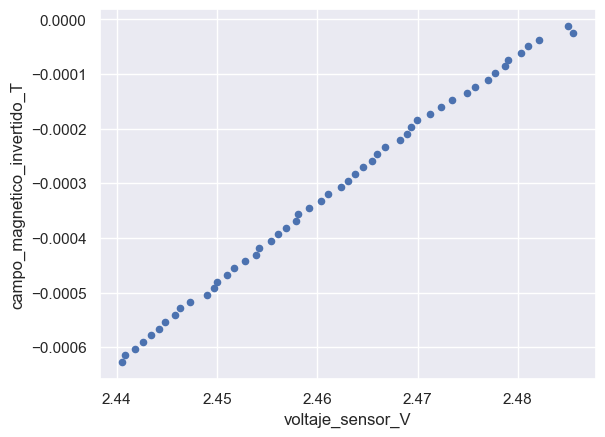

In [280]:
datos_sensor_df.plot(kind='scatter', x='voltaje_sensor_V', y='campo_magnetico_invertido_T')
plt.show()